[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/stats/distributions.ipynb)

# Distributions

A set of numbers, such as the follower counts of many accounts, has a distribution.
This notebook describes a distribution with the mean and the median, and plots it with a histogram, a box plot, a violin plot, a CDF, and a CCDF.
It starts with simulated data and then uses the follower counts of 698 Twitter accounts, which are highly skewed.

Sections: Mean and median, Simulated heights, Box plot and violin plot, Load the Botwiki-2019 data, Histogram of follower counts, Mean and median of a skewed distribution, Box plot on a log axis, CDF and CCDF.

Packages beyond the standard library: `numpy`, `pandas`, `matplotlib`.
Install them with `uv add numpy pandas matplotlib` (or `pip install`).
Colab already has all three.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Figure settings: a larger font, and tick marks drawn behind the data.
plt.rcParams.update({"font.size": 14, "axes.axisbelow": True})

## Mean and median

The mean is the average value.
The median is the middle value when all values are sorted.

The example is the number of likes of seven posts.
Two of the posts have far more likes than the other five.

In [2]:
num_of_likes = pd.Series([5, 8, 10, 12, 15, 100, 200])
print(f"Mean: {num_of_likes.mean()}")
print(f"Median: {num_of_likes.median()}")

Mean: 50.0
Median: 12.0


The mean is 50.0 and the median is 12.0.
The two posts with 100 and 200 likes raise the mean.
Five of the seven posts have fewer than 20 likes, so the median describes a typical post better.

You can also show the whole distribution with a histogram.
`plt.hist` splits the range of the values into bins of the same size, counts the values in each bin, and draws the counts as bars.
Always label the axes.

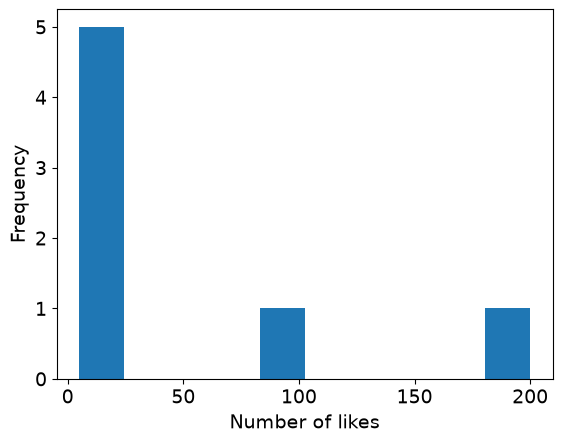

In [3]:
plt.hist(num_of_likes)
plt.xlabel("Number of likes")
plt.ylabel("Frequency")
plt.show()

Five posts are in the first bin.
The two posts with many likes are far to the right.

## Simulated heights

The next example is 1,000 simulated heights.
They come from a normal distribution with a mean of 170 cm and a standard deviation of 10 cm.
`np.clip` limits them to the range from 140 cm to 210 cm.

`np.random.default_rng(415)` creates a random number generator with the seed 415.
With a fixed seed, every run gives the same numbers.

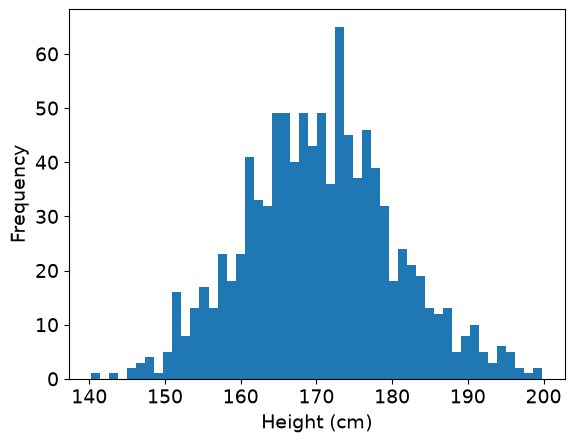

In [4]:
rng = np.random.default_rng(415)
heights = rng.normal(loc=170, scale=10, size=1000)
heights = np.clip(heights, 140, 210)

plt.hist(heights, bins=50)
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.show()

The histogram has one peak near 170 cm, and the two sides have about the same shape.
Now compute the mean and the median, and mark both on the histogram.

In [5]:
print(f"Mean: {np.mean(heights):.2f}")
print(f"Median: {np.median(heights):.2f}")

Mean: 170.55
Median: 170.54


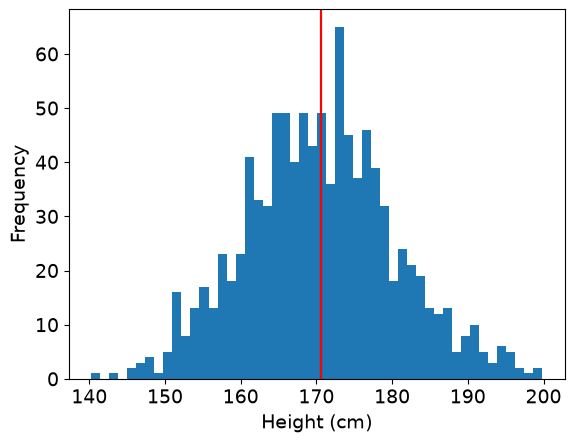

In [6]:
plt.hist(heights, bins=50)
plt.axvline(np.mean(heights), color="black")
plt.axvline(np.median(heights), color="red")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.show()

The mean is 170.55 cm (black line) and the median is 170.54 cm (red line).
The two lines are at the same place.
For a symmetric distribution like this one, either number describes the data well.

## Box plot and violin plot

A box plot shows a distribution in a small space.

- The box runs from the first quartile (Q1) to the third quartile (Q3).
- The line inside the box is the median.
- The interquartile range is IQR = Q3 - Q1.
- Each whisker reaches the farthest data point within 1.5 x IQR of the box.
- Points beyond the whiskers are drawn one by one.

The argument `orientation` needs matplotlib 3.10 or later.

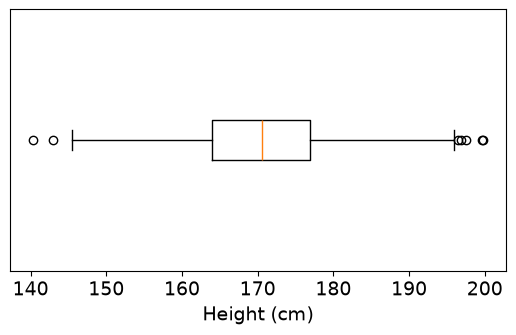

In [7]:
plt.figure(figsize=(6.4, 3.4))
plt.boxplot(heights, orientation="horizontal")
plt.yticks([])    # there is one box, so the y-axis needs no ticks
plt.xlabel("Height (cm)")
plt.show()

The box runs from about 164 cm to about 177 cm, and the median line is near 170.5 cm.
A few points are beyond the whiskers on both sides.

A violin plot also shows the shape of the distribution.
It is wide where there are many data points.
`showmedians=True` draws a line at the median.

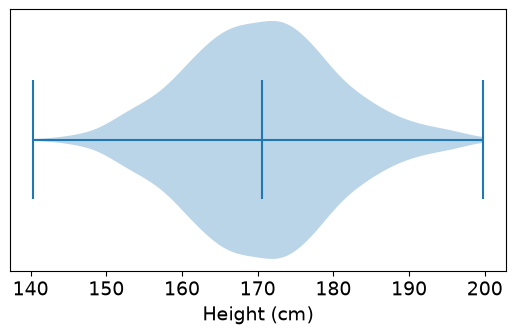

In [8]:
plt.figure(figsize=(6.4, 3.4))
plt.violinplot(heights, orientation="horizontal", showmedians=True)
plt.yticks([])
plt.xlabel("Height (cm)")
plt.show()

## Load the Botwiki-2019 data

The rest of this notebook uses real social media data.

The data is Botwiki-2019: 698 Twitter accounts that identified themselves as bots, from the
[Bot Repository](https://botometer.osome.iu.edu/bot-repository/datasets.html)
([Yang et al., 2020](https://doi.org/10.1609/aaai.v34i01.5460)). The dataset has the license
[CC BY-NC-ND 4.0](https://creativecommons.org/licenses/by-nc-nd/4.0/). This notebook uses two
numbers for each account: the number of followers and the number of friends.

In [9]:
import gzip
import json
import pathlib
import urllib.request

import pandas as pd

# The file is not in the site repository. This cell downloads it once from the
# public course repository, at a fixed commit.
url = (
    "https://raw.githubusercontent.com/YangKCLab/social-media-ds-course/"
    "b4a210426ebfec34f2e983983efde03eeb3dba8d/demos/stats/botwiki-2019_tweets.json.gz"
)
path = pathlib.Path("data") / "botwiki-2019_tweets.json.gz"
path.parent.mkdir(exist_ok=True)
if not path.exists():
    urllib.request.urlretrieve(url, path)

with gzip.open(path) as f:
    botwiki = json.load(f)
botwiki_df = pd.DataFrame.from_records([item["user"] for item in botwiki])
botwiki_df = botwiki_df[["followers_count", "friends_count"]]
len(botwiki_df)    # 698

698

The cell downloads the file (154 KB) into `data/` next to this notebook, unless the file is already there.
The table has 698 rows, one for each account.
The source file has 42 fields for each account, and the cell keeps two of them: `followers_count` and `friends_count`.
Friends are the accounts that an account follows.

## Histogram of follower counts

Start with the same histogram as before, now for the number of followers.

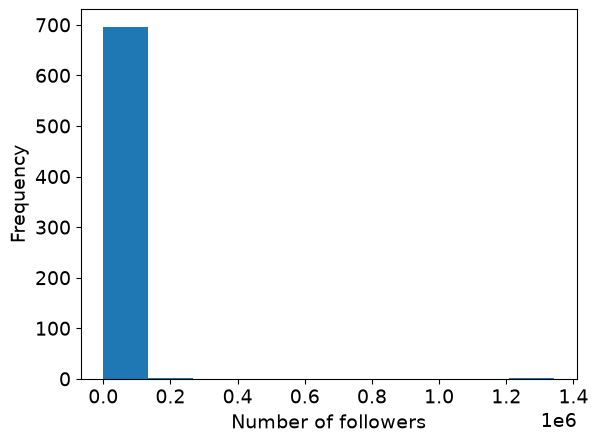

In [10]:
plt.hist(botwiki_df.followers_count)
plt.xlabel("Number of followers")
plt.ylabel("Frequency")
plt.show()

Almost all accounts are in the first bin.
The distribution is highly skewed: a few accounts have very high values, and many accounts have very low values.
Bins of the same size do not work for such data.

Create the bins in log scale instead.
`np.logspace(0, 6.2, num=20)` returns 20 bin edges from 10^0 = 1 to 10^6.2, which is about 1.6 million.

In [11]:
bins = np.logspace(0, 6.2, num=20)
print(bins.round(1).tolist())

[1.0, 2.1, 4.5, 9.5, 20.2, 42.8, 90.8, 192.4, 407.9, 864.7, 1833.0, 3885.7, 8237.4, 17462.5, 37018.7, 78476.0, 166361.4, 352669.9, 747625.7, 1584893.2]


The edges are 1, 2.1, 4.5, 9.5, 20.2, and so on.
Each bin is about 2.1 times as wide as the bin before it.

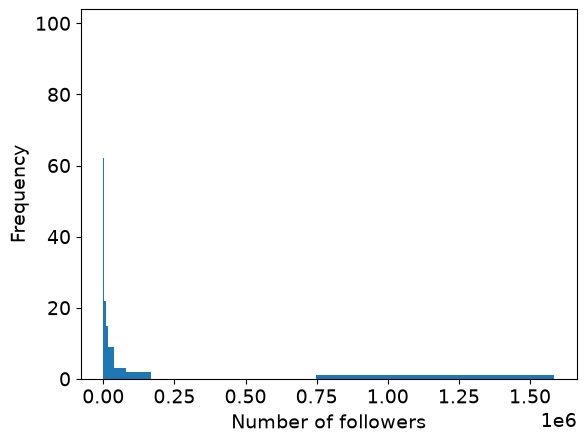

In [12]:
plt.hist(botwiki_df.followers_count, bins=bins)
plt.xlabel("Number of followers")
plt.ylabel("Frequency")
plt.show()

The bins are better, but the x-axis is still linear, so the narrow bins on the left cannot be seen.
Change the x-axis to log scale as well.

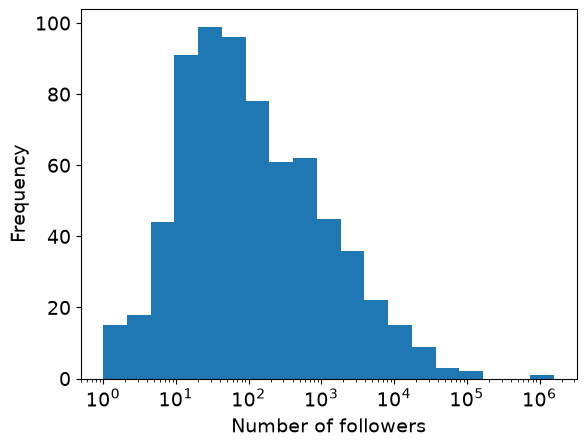

In [13]:
plt.hist(botwiki_df.followers_count, bins=bins)
plt.xscale("log")
plt.xlabel("Number of followers")
plt.ylabel("Frequency")
plt.show()

Now the shape of the distribution is visible.
Be careful when you read this figure, for two reasons.

- The bins differ in size by orders of magnitude.
- A log axis cannot show 0. The next cell counts the accounts with 0 followers.

In [14]:
(botwiki_df.followers_count == 0).sum()

np.int64(1)

One account has 0 followers.
It is not in the plot.

## Mean and median of a skewed distribution

Compute the mean and the median of the follower counts.

In [15]:
print(f"Mean: {botwiki_df.followers_count.mean():.2f}")
print(f"Median: {botwiki_df.followers_count.median()}")

Mean: 3511.87
Median: 81.0


The mean is 3,511.87 followers and the median is 81.
The mean is about 43 times the median.
The next cell computes the share of accounts with fewer followers than the mean.

In [16]:
(botwiki_df.followers_count < botwiki_df.followers_count.mean()).mean()

np.float64(0.9212034383954155)

The share is 0.92: 92% of the accounts are below the mean.
The next plot marks the mean (black line) and the median (red line) on the histogram.

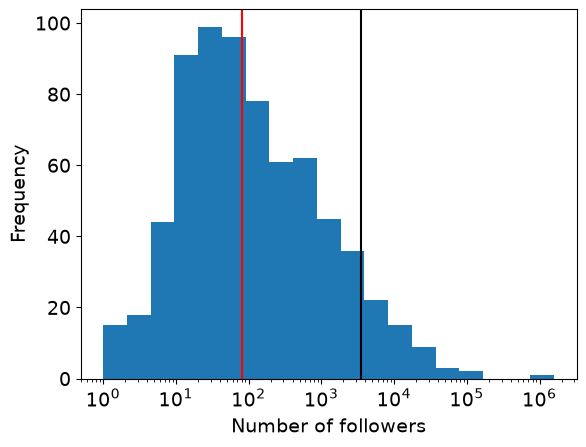

In [17]:
plt.hist(botwiki_df.followers_count, bins=bins)
plt.axvline(botwiki_df.followers_count.mean(), color="black")
plt.axvline(botwiki_df.followers_count.median(), color="red")
plt.xscale("log")
plt.xlabel("Number of followers")
plt.ylabel("Frequency")
plt.show()

The median is in the middle of the accounts.
The mean is far to the right, because a few accounts with very many followers raise it.
For skewed data such as follower counts, report the median.

## Box plot on a log axis

Draw the box plot of the follower counts, first with a linear x-axis.

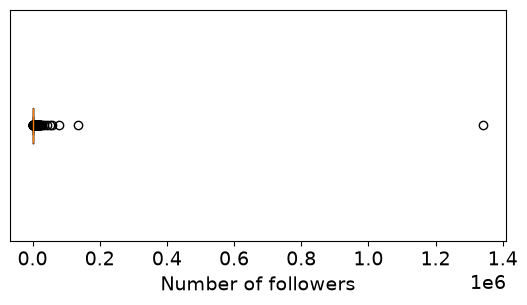

In [18]:
plt.figure(figsize=(6.4, 3.0))
plt.boxplot(botwiki_df.followers_count, orientation="horizontal")
plt.yticks([])
plt.xlabel("Number of followers")
plt.show()

The box is squeezed into a line at the left edge.
The box plot needs the log scale on the x-axis too.

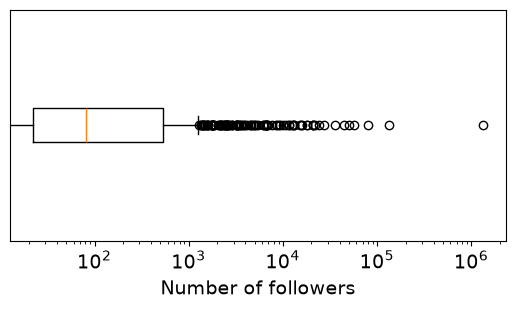

In [19]:
plt.figure(figsize=(6.4, 3.0))
plt.boxplot(botwiki_df.followers_count, orientation="horizontal")
plt.xscale("log")
plt.yticks([])
plt.xlabel("Number of followers")
plt.show()

With the log axis you can see the box, the median line, and the points beyond the right whisker.

## CDF and CCDF

The cumulative distribution function (CDF) gives, for each value x, the share of data points with a value of at most x.
It needs no bins, so you do not have to choose a bin size.
`plt.ecdf` draws it from the data.

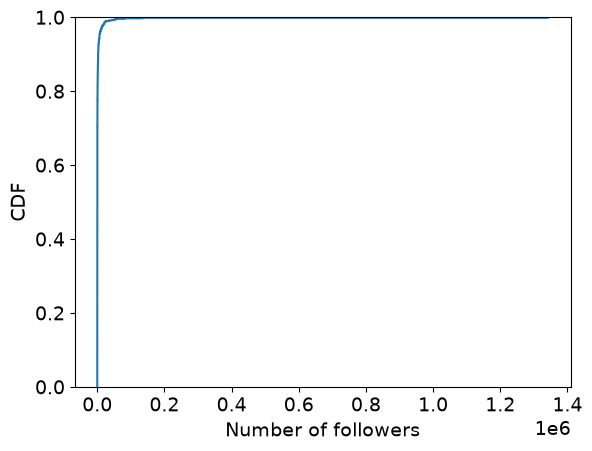

In [20]:
plt.ecdf(botwiki_df.followers_count)
plt.xlabel("Number of followers")
plt.ylabel("CDF")
plt.show()

With a linear x-axis, the curve rises to almost 1 at the left edge of the plot.
Use the log scale again.

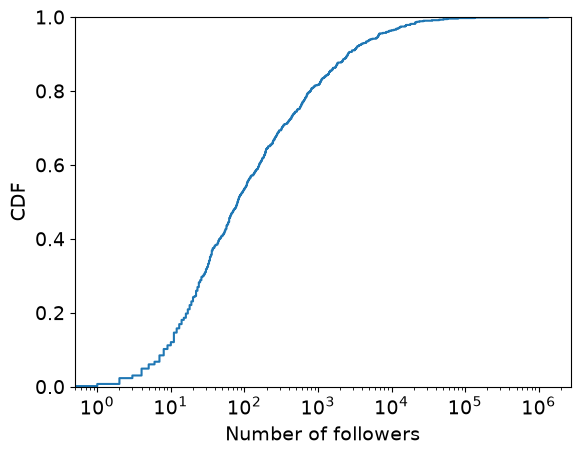

In [21]:
plt.ecdf(botwiki_df.followers_count)
plt.xscale("log")
plt.xlabel("Number of followers")
plt.ylabel("CDF")
plt.show()

To read the CDF, pick a value on the x-axis and read the share on the y-axis.
The next cell computes the share for x = 1,000.

In [22]:
(botwiki_df.followers_count <= 1000).mean()

np.float64(0.8166189111747851)

The share is 0.817: 82% of the accounts have at most 1,000 followers.
The curve has this height at x = 1,000.

The complementary cumulative distribution function (CCDF) gives the share of data points with a value larger than x.
CCDF = 1 - CDF.

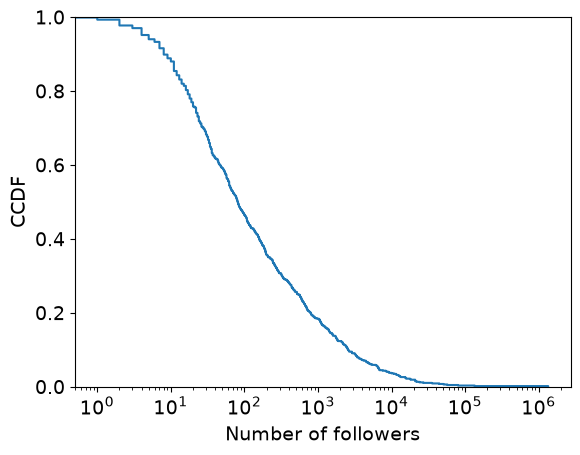

In [23]:
plt.ecdf(botwiki_df.followers_count, complementary=True)
plt.xscale("log")
plt.xlabel("Number of followers")
plt.ylabel("CCDF")
plt.show()

At x = 1,000 the CCDF is 1 - 0.817 = 0.183: 18% of the accounts have more than 1,000 followers.